In [1]:
# HELPER IMPORTS AND FUNCTIONS: Chapter 7 classification exercises.
# ---------------------------------------------------------------------
# This cell consolidates the imports, plotting defaults, optimization
# routines, cost functions, prediction helpers, and reusable datasets used
# across the Chapter 7 notebook exercises.  Each exercise cell below repeats these helpers locally so it can run on its own.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Keep all plots on a neutral light background regardless of the notebook's
# previous matplotlib state.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

CLASS_COLORS_4 = ["tab:blue", "tab:red", "tab:green", "gold"]
REGION_CMAP_4 = ListedColormap(["#cfe8ff", "#ffd9d9", "#d8f2d8", "#fff4bf"])
CLASS_COLORS_3 = ["tab:blue", "tab:red", "tab:green"]
REGION_CMAP_3 = ListedColormap(["#d7ebff", "#ffd9d9", "#ddf5dd"])


def linear_model(X, w):
    # Affine score a(x) = w0 + w1 * x1 + ... + wN * xN.
    return w[0] + X @ w[1:]


def sigmoid(z):
    # Logistic sigmoid used in the two-class softmax loss.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))


def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=0.5, max_its=250):
    # Full-batch gradient descent: every update uses the entire training set
    # X, y to compute one exact gradient of the current objective.
    #
    # This is the "normal" gradient descent baseline used in Exercise 7.11.
    # One loop iteration below means:
    # 1. evaluate grad_fn on all training points
    # 2. take one step W <- W - alpha * grad
    # 3. store the updated weights and the full-data cost
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def mini_batch_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, epochs=10, batch_size=200, seed=0):
    # Mini-batch gradient descent: each epoch first shuffles the training set,
    # then breaks it into chunks of size batch_size, and takes one parameter
    # update per chunk.
    #
    # Compared with full-batch gradient descent above, this produces many more
    # cheaper updates per epoch.  The direction of each update is noisier,
    # because it is computed from only part of the data, but in practice this
    # often drives the objective down faster.
    #
    # The full training cost is still recorded only once per epoch so that the
    # resulting history can be compared fairly against full-batch GD.
    rng = np.random.RandomState(seed)
    w = w0.astype(float).copy()
    num_points = X.shape[0]
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(epochs):
        # Randomize the order each epoch so batches do not present the same
        # local view of the data on every pass.
        order = rng.permutation(num_points)
        for start in range(0, num_points, batch_size):
            batch_inds = order[start:start + batch_size]
            # This is the key difference from full-batch GD: the gradient is
            # computed on the current batch only, not on all num_points.
            w = w - alpha * grad_fn(w, X[batch_inds], y[batch_inds])
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def multiclass_scores(X, W):
    # Compute one affine score per class.
    #
    # W has shape (number_of_classes, number_of_features + 1).  The first
    # column stores the class bias terms, and the remaining columns store the
    # feature weights.  For each point x_p this returns the class-score vector
    # [w_0^T xbar_p, ..., w_{C-1}^T xbar_p].
    return W[:, 0][None, :] + X @ W[:, 1:].T


def multiclass_predict(X, W):
    # Predict the class whose score is largest.
    return np.argmax(multiclass_scores(X, W), axis=1)


def misclassifications_multiclass(preds, y):
    return int(np.sum(preds != y))


def misclass_history(X, y, weight_history, predict_fn=multiclass_predict):
    # Count mistakes after each saved iterate.
    return np.array([
        misclassifications_multiclass(predict_fn(X, weights), y)
        for weights in weight_history
    ])


def one_vs_all_labels(y, target_class):
    # Temporary labels for one-versus-all training: +1 for class c, -1 otherwise.
    return np.where(y == target_class, 1.0, -1.0)


def signed_distance_scores(X, w, eps=1e-12):
    # Normalize by the feature-weight norm so OvA scores are comparable.
    norm_omega = max(np.linalg.norm(w[1:]), eps)
    return linear_model(X, w) / norm_omega


def ova_predict(X, classifiers):
    # Evaluate all one-versus-all classifiers and choose the largest normalized
    # signed distance.
    fusion_scores = np.column_stack([signed_distance_scores(X, w) for w in classifiers])
    return np.argmax(fusion_scores, axis=1)


def softmax_cost_signed(w, X, y):
    # Two-class softmax loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))


def grad_softmax_signed(w, X, y):
    # Gradient of the signed softmax loss.
    margins = y * linear_model(X, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X.T @ coeff) / X.shape[0]
    return np.concatenate([[grad_w0], grad_rest])


def multiclass_perceptron_cost(W, X, y):
    # Compare the true-class score against the strongest competing class score.
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(X.shape[0]), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(X.shape[0]), y] = -np.inf
    worst_margin = np.max(margins, axis=1)
    return np.mean(np.maximum(0.0, worst_margin))


def multiclass_perceptron_gradient(W, X, y):
    # Subgradient of the multiclass perceptron cost.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(num_points), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(num_points), y] = -np.inf
    worst_classes = np.argmax(margins, axis=1)
    worst_margins = margins[np.arange(num_points), worst_classes]

    gradient = np.zeros_like(W)
    active = np.where(worst_margins > 0)[0]
    if active.size == 0:
        return gradient

    X_aug = np.column_stack([np.ones(num_points), X]) / num_points
    np.add.at(gradient, worst_classes[active], X_aug[active])
    np.add.at(gradient, y[active], -X_aug[active])
    return gradient


def multiclass_softmax_cost(W, X, y, lam=1e-4):
    # Stable multiclass softmax cost with a small L2 penalty on feature weights.
    #
    # For each point p with true class y_p, the data-fitting term is
    #
    #   log(sum_j exp(score_{p,j})) - score_{p, y_p}
    #
    # which penalizes the model unless the true-class score is large relative
    # to the scores of all competing classes.
    #
    # We subtract the largest score in each row before exponentiating.  This
    # leaves the softmax value unchanged but prevents numerical overflow.
    scores = multiclass_scores(X, W)
    row_max = np.max(scores, axis=1, keepdims=True)
    stabilized_scores = scores - row_max
    log_partition = np.log(np.sum(np.exp(stabilized_scores), axis=1)) + row_max.ravel()
    data_cost = np.mean(log_partition - scores[np.arange(X.shape[0]), y])
    # Regularize only the feature weights, not the bias column.
    regularizer = 0.5 * lam * np.sum(W[:, 1:] ** 2)
    return data_cost + regularizer


def multiclass_softmax_gradient(W, X, y, lam=1e-4):
    # Gradient of the multiclass softmax cost.
    #
    # After converting scores into softmax probabilities p_{p,j}, the gradient
    # is driven by the difference between those probabilities and a one-hot
    # encoding of the true label.  In symbols, the score-level residual is
    #
    #   p_{p,j} - 1(j = y_p)
    #
    # The matrix multiply against X_aug then turns those residuals into one
    # gradient row per class.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    stabilized_scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(stabilized_scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # targets[p, j] equals 1 exactly when class j is the true class for point p.
    targets = np.zeros_like(probabilities)
    targets[np.arange(num_points), y] = 1.0

    # Augment each input with a leading 1 so the bias gradient and feature
    # gradients can be computed in one matrix multiply.
    X_aug = np.column_stack([np.ones(num_points), X])
    gradient = ((probabilities - targets).T @ X_aug) / num_points
    # Again, regularize only the feature weights.
    gradient[:, 1:] += lam * W[:, 1:]
    return gradient


def make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75):
    # Synthetic four-class dataset used for Exercises 7.2 and 7.5.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.0, -1.6],
        [-1.7,  2.1],
        [ 2.0,  2.0],
    ])
    cov = np.array([[std, 0.12], [0.12, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_perceptron_toy_dataset(seed=4, n_per_class=60, std=0.30):
    # Synthetic three-class dataset used for Exercise 7.3.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.2, -1.6],
        [ 0.1,  2.4],
    ])
    cov = np.array([[std, 0.05], [0.05, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_decision_grid(X, pad=1.0, num=300):
    # Build a dense 2D grid for region and contour plots.
    x1_vals = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, num)
    x2_vals = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, num)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])
    return x1_vals, x2_vals, X1, X2, X_grid


def plot_class_scatter(ax, X, y, class_colors, size=28, alpha=0.85, add_labels=False):
    # Scatter plot of a 2D labeled dataset.
    for c, color in enumerate(class_colors):
        kwargs = {"label": f"class {c}"} if add_labels else {}
        ax.scatter(X[y == c, 0], X[y == c, 1], s=size, color=color, alpha=alpha, **kwargs)


def load_local_digits_data(test_size=0.25, random_state=7):
    # Local handwritten-digit dataset used as a self-contained fallback for the
    # chapter's digit-recognition experiment.
    X_digits, y_digits = load_digits(return_X_y=True)
    X_digits = X_digits.astype(float) / 16.0
    return train_test_split(
        X_digits,
        y_digits,
        test_size=test_size,
        random_state=random_state,
        stratify=y_digits,
    )


Total misclassifications: 7
Per-class prediction counts: [75 76 75 74]
Target: fewer than 10 misclassifications


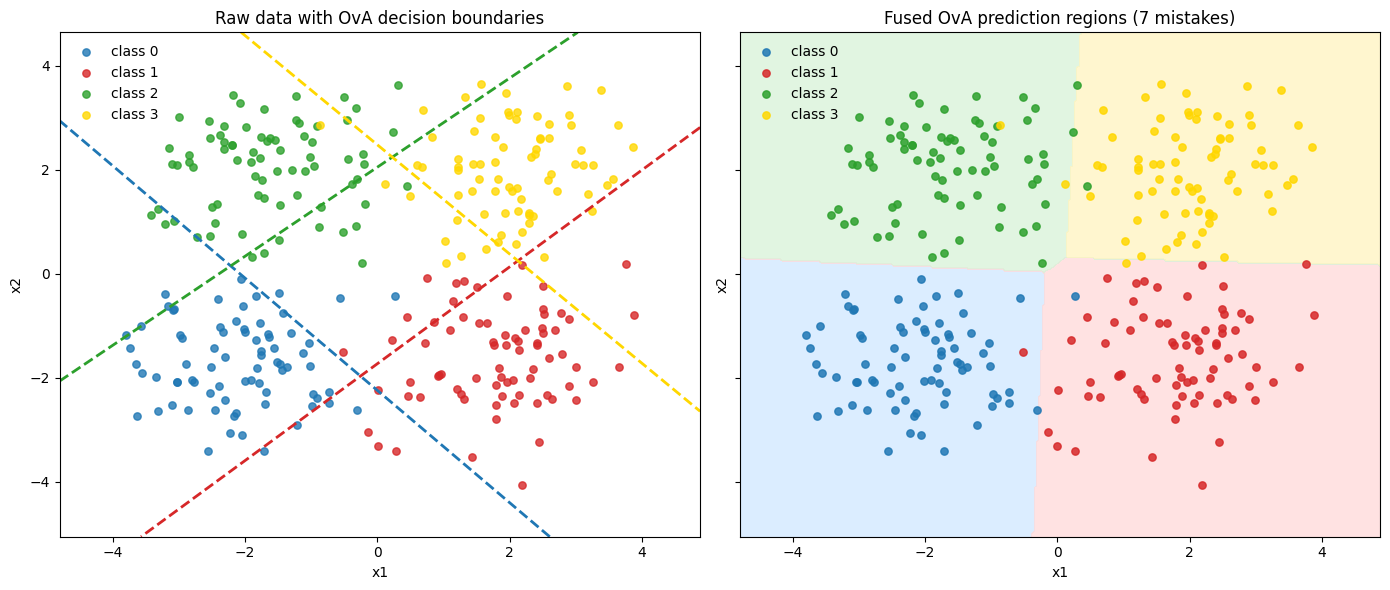

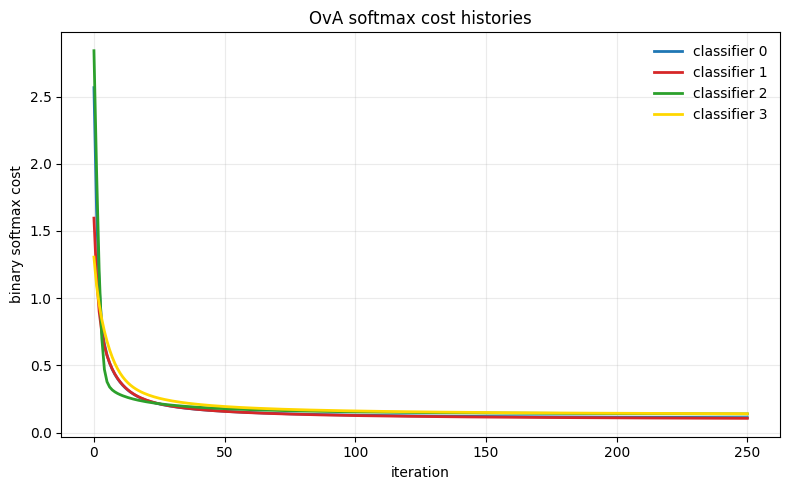

In [2]:
# QUESTION HANDLED: Exercise 7.2 - One-versus-All classification.
# ---------------------------------------------------------------------
# Recreate the Example 7.1 style OvA experiment using a synthetic 2D dataset
# with C = 4 classes.  For each class c we train a two-class softmax classifier
# that separates class c from the remaining classes, then combine all learned
# classifiers with the normalized one-versus-all fusion rule.
# ---------------------------------------------------------------------

# Build the dataset and train one classifier per class.
# Textbook equations used here: the OvA label rule in Equation (7.5), the
# normalization in Equation (7.8), and the fusion rule in Equation (7.12).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS: Chapter 7 classification exercises.
# ---------------------------------------------------------------------
# This cell consolidates the imports, plotting defaults, optimization
# routines, cost functions, prediction helpers, and reusable datasets used
# across the Chapter 7 notebook exercises.  Each exercise cell below repeats these helpers locally so it can run on its own.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Keep all plots on a neutral light background regardless of the notebook's
# previous matplotlib state.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

CLASS_COLORS_4 = ["tab:blue", "tab:red", "tab:green", "gold"]
REGION_CMAP_4 = ListedColormap(["#cfe8ff", "#ffd9d9", "#d8f2d8", "#fff4bf"])
CLASS_COLORS_3 = ["tab:blue", "tab:red", "tab:green"]
REGION_CMAP_3 = ListedColormap(["#d7ebff", "#ffd9d9", "#ddf5dd"])


def linear_model(X, w):
    # Affine score a(x) = w0 + w1 * x1 + ... + wN * xN.
    return w[0] + X @ w[1:]


def sigmoid(z):
    # Logistic sigmoid used in the two-class softmax loss.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))


def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=0.5, max_its=250):
    # Full-batch gradient descent: every update uses the entire training set
    # X, y to compute one exact gradient of the current objective.
    #
    # This is the "normal" gradient descent baseline used in Exercise 7.11.
    # One loop iteration below means:
    # 1. evaluate grad_fn on all training points
    # 2. take one step W <- W - alpha * grad
    # 3. store the updated weights and the full-data cost
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def mini_batch_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, epochs=10, batch_size=200, seed=0):
    # Mini-batch gradient descent: each epoch first shuffles the training set,
    # then breaks it into chunks of size batch_size, and takes one parameter
    # update per chunk.
    #
    # Compared with full-batch gradient descent above, this produces many more
    # cheaper updates per epoch.  The direction of each update is noisier,
    # because it is computed from only part of the data, but in practice this
    # often drives the objective down faster.
    #
    # The full training cost is still recorded only once per epoch so that the
    # resulting history can be compared fairly against full-batch GD.
    rng = np.random.RandomState(seed)
    w = w0.astype(float).copy()
    num_points = X.shape[0]
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(epochs):
        # Randomize the order each epoch so batches do not present the same
        # local view of the data on every pass.
        order = rng.permutation(num_points)
        for start in range(0, num_points, batch_size):
            batch_inds = order[start:start + batch_size]
            # This is the key difference from full-batch GD: the gradient is
            # computed on the current batch only, not on all num_points.
            w = w - alpha * grad_fn(w, X[batch_inds], y[batch_inds])
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def multiclass_scores(X, W):
    # Compute one affine score per class.
    #
    # W has shape (number_of_classes, number_of_features + 1).  The first
    # column stores the class bias terms, and the remaining columns store the
    # feature weights.  For each point x_p this returns the class-score vector
    # [w_0^T xbar_p, ..., w_{C-1}^T xbar_p].
    return W[:, 0][None, :] + X @ W[:, 1:].T


def multiclass_predict(X, W):
    # Predict the class whose score is largest.
    return np.argmax(multiclass_scores(X, W), axis=1)


def misclassifications_multiclass(preds, y):
    return int(np.sum(preds != y))


def misclass_history(X, y, weight_history, predict_fn=multiclass_predict):
    # Count mistakes after each saved iterate.
    return np.array([
        misclassifications_multiclass(predict_fn(X, weights), y)
        for weights in weight_history
    ])


def one_vs_all_labels(y, target_class):
    # Temporary labels for one-versus-all training: +1 for class c, -1 otherwise.
    return np.where(y == target_class, 1.0, -1.0)


def signed_distance_scores(X, w, eps=1e-12):
    # Normalize by the feature-weight norm so OvA scores are comparable.
    norm_omega = max(np.linalg.norm(w[1:]), eps)
    return linear_model(X, w) / norm_omega


def ova_predict(X, classifiers):
    # Evaluate all one-versus-all classifiers and choose the largest normalized
    # signed distance.
    fusion_scores = np.column_stack([signed_distance_scores(X, w) for w in classifiers])
    return np.argmax(fusion_scores, axis=1)


def softmax_cost_signed(w, X, y):
    # Two-class softmax loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))


def grad_softmax_signed(w, X, y):
    # Gradient of the signed softmax loss.
    margins = y * linear_model(X, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X.T @ coeff) / X.shape[0]
    return np.concatenate([[grad_w0], grad_rest])


def multiclass_perceptron_cost(W, X, y):
    # Compare the true-class score against the strongest competing class score.
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(X.shape[0]), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(X.shape[0]), y] = -np.inf
    worst_margin = np.max(margins, axis=1)
    return np.mean(np.maximum(0.0, worst_margin))


def multiclass_perceptron_gradient(W, X, y):
    # Subgradient of the multiclass perceptron cost.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(num_points), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(num_points), y] = -np.inf
    worst_classes = np.argmax(margins, axis=1)
    worst_margins = margins[np.arange(num_points), worst_classes]

    gradient = np.zeros_like(W)
    active = np.where(worst_margins > 0)[0]
    if active.size == 0:
        return gradient

    X_aug = np.column_stack([np.ones(num_points), X]) / num_points
    np.add.at(gradient, worst_classes[active], X_aug[active])
    np.add.at(gradient, y[active], -X_aug[active])
    return gradient


def multiclass_softmax_cost(W, X, y, lam=1e-4):
    # Stable multiclass softmax cost with a small L2 penalty on feature weights.
    #
    # For each point p with true class y_p, the data-fitting term is
    #
    #   log(sum_j exp(score_{p,j})) - score_{p, y_p}
    #
    # which penalizes the model unless the true-class score is large relative
    # to the scores of all competing classes.
    #
    # We subtract the largest score in each row before exponentiating.  This
    # leaves the softmax value unchanged but prevents numerical overflow.
    scores = multiclass_scores(X, W)
    row_max = np.max(scores, axis=1, keepdims=True)
    stabilized_scores = scores - row_max
    log_partition = np.log(np.sum(np.exp(stabilized_scores), axis=1)) + row_max.ravel()
    data_cost = np.mean(log_partition - scores[np.arange(X.shape[0]), y])
    # Regularize only the feature weights, not the bias column.
    regularizer = 0.5 * lam * np.sum(W[:, 1:] ** 2)
    return data_cost + regularizer


def multiclass_softmax_gradient(W, X, y, lam=1e-4):
    # Gradient of the multiclass softmax cost.
    #
    # After converting scores into softmax probabilities p_{p,j}, the gradient
    # is driven by the difference between those probabilities and a one-hot
    # encoding of the true label.  In symbols, the score-level residual is
    #
    #   p_{p,j} - 1(j = y_p)
    #
    # The matrix multiply against X_aug then turns those residuals into one
    # gradient row per class.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    stabilized_scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(stabilized_scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # targets[p, j] equals 1 exactly when class j is the true class for point p.
    targets = np.zeros_like(probabilities)
    targets[np.arange(num_points), y] = 1.0

    # Augment each input with a leading 1 so the bias gradient and feature
    # gradients can be computed in one matrix multiply.
    X_aug = np.column_stack([np.ones(num_points), X])
    gradient = ((probabilities - targets).T @ X_aug) / num_points
    # Again, regularize only the feature weights.
    gradient[:, 1:] += lam * W[:, 1:]
    return gradient


def make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75):
    # Synthetic four-class dataset used for Exercises 7.2 and 7.5.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.0, -1.6],
        [-1.7,  2.1],
        [ 2.0,  2.0],
    ])
    cov = np.array([[std, 0.12], [0.12, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_perceptron_toy_dataset(seed=4, n_per_class=60, std=0.30):
    # Synthetic three-class dataset used for Exercise 7.3.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.2, -1.6],
        [ 0.1,  2.4],
    ])
    cov = np.array([[std, 0.05], [0.05, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_decision_grid(X, pad=1.0, num=300):
    # Build a dense 2D grid for region and contour plots.
    x1_vals = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, num)
    x2_vals = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, num)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])
    return x1_vals, x2_vals, X1, X2, X_grid


def plot_class_scatter(ax, X, y, class_colors, size=28, alpha=0.85, add_labels=False):
    # Scatter plot of a 2D labeled dataset.
    for c, color in enumerate(class_colors):
        kwargs = {"label": f"class {c}"} if add_labels else {}
        ax.scatter(X[y == c, 0], X[y == c, 1], s=size, color=color, alpha=alpha, **kwargs)


def load_local_digits_data(test_size=0.25, random_state=7):
    # Local handwritten-digit dataset used as a self-contained fallback for the
    # chapter's digit-recognition experiment.
    X_digits, y_digits = load_digits(return_X_y=True)
    X_digits = X_digits.astype(float) / 16.0
    return train_test_split(
        X_digits,
        y_digits,
        test_size=test_size,
        random_state=random_state,
        stratify=y_digits,
    )

X, y = make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75)
num_classes = len(np.unique(y))

classifiers = []
cost_histories = []

for c in range(num_classes):
    y_binary = one_vs_all_labels(y, c)
    w_init = np.random.RandomState(c).randn(X.shape[1] + 1)
    weight_history, cost_history = gradient_descent(
        softmax_cost_signed,
        grad_softmax_signed,
        w_init,
        X,
        y_binary,
        alpha=0.5,
        max_its=250,
    )
    classifiers.append(weight_history[-1])
    cost_histories.append(cost_history)

classifiers = np.array(classifiers)
predictions = ova_predict(X, classifiers)
num_misclassifications = misclassifications_multiclass(predictions, y)

print("Total misclassifications:", num_misclassifications)
print("Per-class prediction counts:", np.bincount(predictions, minlength=num_classes))
print("Target: fewer than 10 misclassifications")

# Visualize the raw data and the fused multi-class decision regions.
class_colors = CLASS_COLORS_4
region_cmap = REGION_CMAP_4
x1_vals, x2_vals, X1, X2, X_grid = make_decision_grid(X, pad=1.0, num=300)
grid_predictions = ova_predict(X_grid, classifiers).reshape(X1.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left panel: data and all four individual OvA decision boundaries.
plot_class_scatter(axes[0], X, y, class_colors, size=28, alpha=0.80, add_labels=True)
for c, color in enumerate(class_colors):
    class_scores = linear_model(X_grid, classifiers[c]).reshape(X1.shape)
    axes[0].contour(X1, X2, class_scores, levels=[0], colors=[color], linewidths=2, linestyles="--")
axes[0].set_title("Raw data with OvA decision boundaries")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend(loc="upper left", frameon=False)

# Right panel: fused multi-class regions from the normalized fusion rule.
axes[1].contourf(X1, X2, grid_predictions, levels=np.arange(-0.5, num_classes + 0.5, 1), cmap=region_cmap, alpha=0.75)
plot_class_scatter(axes[1], X, y, class_colors, size=28, alpha=0.85, add_labels=True)
axes[1].set_title(f"Fused OvA prediction regions ({num_misclassifications} mistakes)")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

# Plot the four binary softmax objective histories to confirm the individual
# OvA subproblems were optimized successfully.
plt.figure(figsize=(8, 5))
for c, (cost_history, color) in enumerate(zip(cost_histories, class_colors)):
    plt.plot(cost_history, linewidth=2, color=color, label=f"classifier {c}")
plt.xlabel("iteration")
plt.ylabel("binary softmax cost")
plt.title("OvA softmax cost histories")
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


Final misclassifications: 0
Minimum misclassifications during optimization: 0
First zero-misclassification step: 35
Left panel: individual zero-score lines. Right panel: fused argmax decision regions.


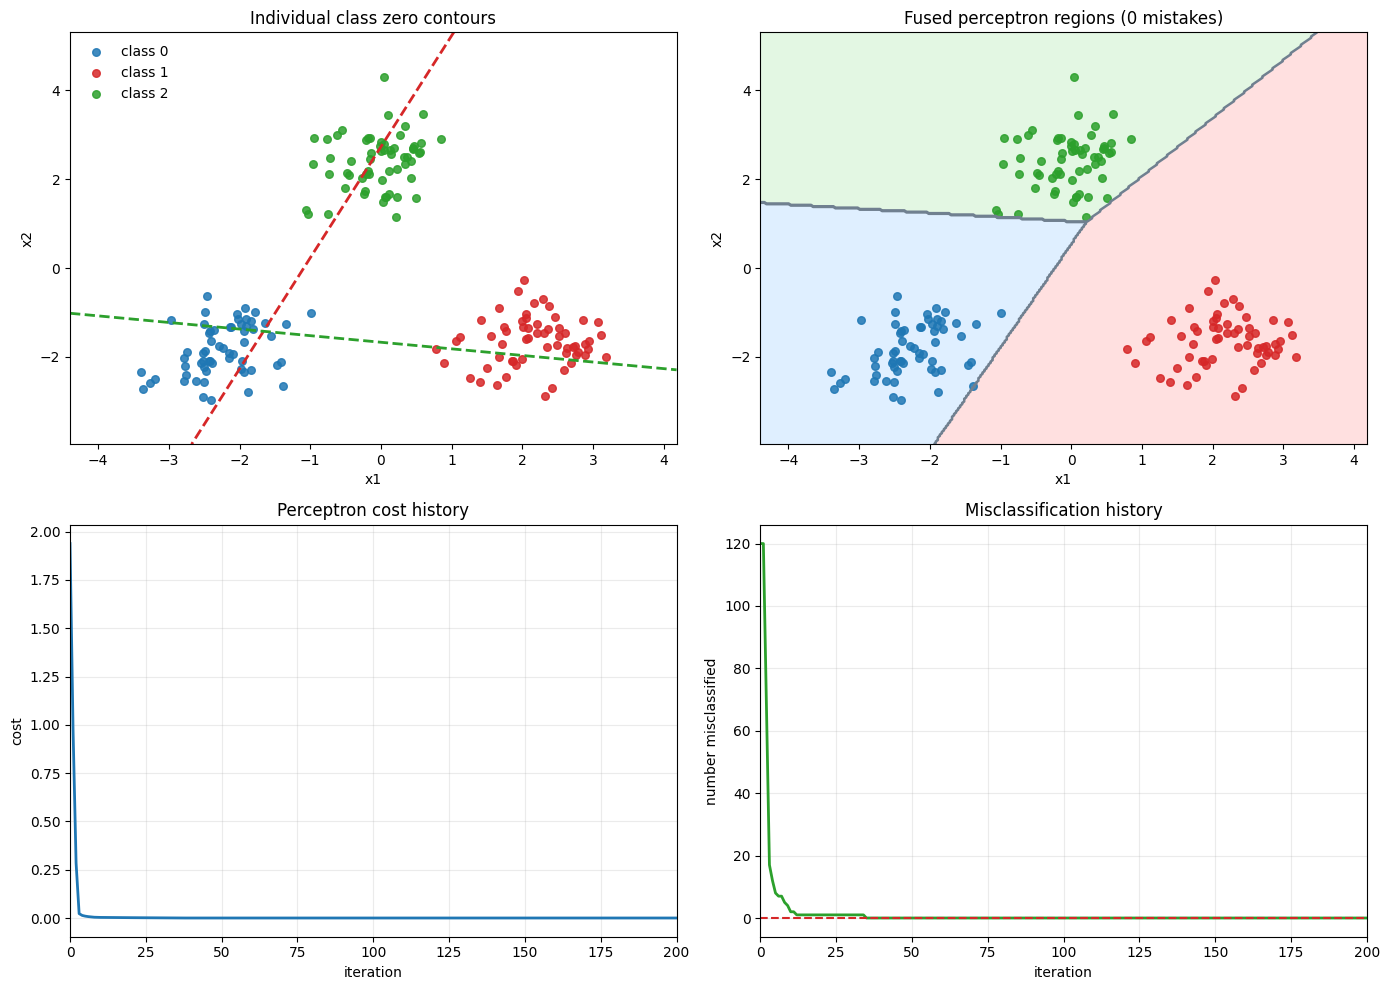

In [3]:
# QUESTION HANDLED: Exercise 7.3 - Multi-class Perceptron.
# ---------------------------------------------------------------------
# Match Example 7.3 from the chapter more closely by using a dedicated 3-class
# toy dataset and the multi-class perceptron cost from Equation (7.16).  This
# is a separate setup from Exercise 7.2, which uses a 4-class OvA example.
# The goal here is to verify that the jointly trained fused classifier reaches
# zero training misclassifications, as described for Figure 7.9.
# ---------------------------------------------------------------------

# Build a linearly separable three-class dataset and optimize the multi-class
# perceptron objective with fixed-step gradient descent.
# Textbook equations used here: the multi-class Perceptron cost in Equation (7.16)
# and its max-based form in Equation (7.18).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS: Chapter 7 classification exercises.
# ---------------------------------------------------------------------
# This cell consolidates the imports, plotting defaults, optimization
# routines, cost functions, prediction helpers, and reusable datasets used
# across the Chapter 7 notebook exercises.  Each exercise cell below repeats these helpers locally so it can run on its own.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Keep all plots on a neutral light background regardless of the notebook's
# previous matplotlib state.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

CLASS_COLORS_4 = ["tab:blue", "tab:red", "tab:green", "gold"]
REGION_CMAP_4 = ListedColormap(["#cfe8ff", "#ffd9d9", "#d8f2d8", "#fff4bf"])
CLASS_COLORS_3 = ["tab:blue", "tab:red", "tab:green"]
REGION_CMAP_3 = ListedColormap(["#d7ebff", "#ffd9d9", "#ddf5dd"])


def linear_model(X, w):
    # Affine score a(x) = w0 + w1 * x1 + ... + wN * xN.
    return w[0] + X @ w[1:]


def sigmoid(z):
    # Logistic sigmoid used in the two-class softmax loss.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))


def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=0.5, max_its=250):
    # Full-batch gradient descent: every update uses the entire training set
    # X, y to compute one exact gradient of the current objective.
    #
    # This is the "normal" gradient descent baseline used in Exercise 7.11.
    # One loop iteration below means:
    # 1. evaluate grad_fn on all training points
    # 2. take one step W <- W - alpha * grad
    # 3. store the updated weights and the full-data cost
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def mini_batch_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, epochs=10, batch_size=200, seed=0):
    # Mini-batch gradient descent: each epoch first shuffles the training set,
    # then breaks it into chunks of size batch_size, and takes one parameter
    # update per chunk.
    #
    # Compared with full-batch gradient descent above, this produces many more
    # cheaper updates per epoch.  The direction of each update is noisier,
    # because it is computed from only part of the data, but in practice this
    # often drives the objective down faster.
    #
    # The full training cost is still recorded only once per epoch so that the
    # resulting history can be compared fairly against full-batch GD.
    rng = np.random.RandomState(seed)
    w = w0.astype(float).copy()
    num_points = X.shape[0]
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(epochs):
        # Randomize the order each epoch so batches do not present the same
        # local view of the data on every pass.
        order = rng.permutation(num_points)
        for start in range(0, num_points, batch_size):
            batch_inds = order[start:start + batch_size]
            # This is the key difference from full-batch GD: the gradient is
            # computed on the current batch only, not on all num_points.
            w = w - alpha * grad_fn(w, X[batch_inds], y[batch_inds])
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def multiclass_scores(X, W):
    # Compute one affine score per class.
    #
    # W has shape (number_of_classes, number_of_features + 1).  The first
    # column stores the class bias terms, and the remaining columns store the
    # feature weights.  For each point x_p this returns the class-score vector
    # [w_0^T xbar_p, ..., w_{C-1}^T xbar_p].
    return W[:, 0][None, :] + X @ W[:, 1:].T


def multiclass_predict(X, W):
    # Predict the class whose score is largest.
    return np.argmax(multiclass_scores(X, W), axis=1)


def misclassifications_multiclass(preds, y):
    return int(np.sum(preds != y))


def misclass_history(X, y, weight_history, predict_fn=multiclass_predict):
    # Count mistakes after each saved iterate.
    return np.array([
        misclassifications_multiclass(predict_fn(X, weights), y)
        for weights in weight_history
    ])


def one_vs_all_labels(y, target_class):
    # Temporary labels for one-versus-all training: +1 for class c, -1 otherwise.
    return np.where(y == target_class, 1.0, -1.0)


def signed_distance_scores(X, w, eps=1e-12):
    # Normalize by the feature-weight norm so OvA scores are comparable.
    norm_omega = max(np.linalg.norm(w[1:]), eps)
    return linear_model(X, w) / norm_omega


def ova_predict(X, classifiers):
    # Evaluate all one-versus-all classifiers and choose the largest normalized
    # signed distance.
    fusion_scores = np.column_stack([signed_distance_scores(X, w) for w in classifiers])
    return np.argmax(fusion_scores, axis=1)


def softmax_cost_signed(w, X, y):
    # Two-class softmax loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))


def grad_softmax_signed(w, X, y):
    # Gradient of the signed softmax loss.
    margins = y * linear_model(X, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X.T @ coeff) / X.shape[0]
    return np.concatenate([[grad_w0], grad_rest])


def multiclass_perceptron_cost(W, X, y):
    # Compare the true-class score against the strongest competing class score.
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(X.shape[0]), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(X.shape[0]), y] = -np.inf
    worst_margin = np.max(margins, axis=1)
    return np.mean(np.maximum(0.0, worst_margin))


def multiclass_perceptron_gradient(W, X, y):
    # Subgradient of the multiclass perceptron cost.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(num_points), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(num_points), y] = -np.inf
    worst_classes = np.argmax(margins, axis=1)
    worst_margins = margins[np.arange(num_points), worst_classes]

    gradient = np.zeros_like(W)
    active = np.where(worst_margins > 0)[0]
    if active.size == 0:
        return gradient

    X_aug = np.column_stack([np.ones(num_points), X]) / num_points
    np.add.at(gradient, worst_classes[active], X_aug[active])
    np.add.at(gradient, y[active], -X_aug[active])
    return gradient


def multiclass_softmax_cost(W, X, y, lam=1e-4):
    # Stable multiclass softmax cost with a small L2 penalty on feature weights.
    #
    # For each point p with true class y_p, the data-fitting term is
    #
    #   log(sum_j exp(score_{p,j})) - score_{p, y_p}
    #
    # which penalizes the model unless the true-class score is large relative
    # to the scores of all competing classes.
    #
    # We subtract the largest score in each row before exponentiating.  This
    # leaves the softmax value unchanged but prevents numerical overflow.
    scores = multiclass_scores(X, W)
    row_max = np.max(scores, axis=1, keepdims=True)
    stabilized_scores = scores - row_max
    log_partition = np.log(np.sum(np.exp(stabilized_scores), axis=1)) + row_max.ravel()
    data_cost = np.mean(log_partition - scores[np.arange(X.shape[0]), y])
    # Regularize only the feature weights, not the bias column.
    regularizer = 0.5 * lam * np.sum(W[:, 1:] ** 2)
    return data_cost + regularizer


def multiclass_softmax_gradient(W, X, y, lam=1e-4):
    # Gradient of the multiclass softmax cost.
    #
    # After converting scores into softmax probabilities p_{p,j}, the gradient
    # is driven by the difference between those probabilities and a one-hot
    # encoding of the true label.  In symbols, the score-level residual is
    #
    #   p_{p,j} - 1(j = y_p)
    #
    # The matrix multiply against X_aug then turns those residuals into one
    # gradient row per class.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    stabilized_scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(stabilized_scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # targets[p, j] equals 1 exactly when class j is the true class for point p.
    targets = np.zeros_like(probabilities)
    targets[np.arange(num_points), y] = 1.0

    # Augment each input with a leading 1 so the bias gradient and feature
    # gradients can be computed in one matrix multiply.
    X_aug = np.column_stack([np.ones(num_points), X])
    gradient = ((probabilities - targets).T @ X_aug) / num_points
    # Again, regularize only the feature weights.
    gradient[:, 1:] += lam * W[:, 1:]
    return gradient


def make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75):
    # Synthetic four-class dataset used for Exercises 7.2 and 7.5.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.0, -1.6],
        [-1.7,  2.1],
        [ 2.0,  2.0],
    ])
    cov = np.array([[std, 0.12], [0.12, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_perceptron_toy_dataset(seed=4, n_per_class=60, std=0.30):
    # Synthetic three-class dataset used for Exercise 7.3.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.2, -1.6],
        [ 0.1,  2.4],
    ])
    cov = np.array([[std, 0.05], [0.05, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_decision_grid(X, pad=1.0, num=300):
    # Build a dense 2D grid for region and contour plots.
    x1_vals = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, num)
    x2_vals = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, num)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])
    return x1_vals, x2_vals, X1, X2, X_grid


def plot_class_scatter(ax, X, y, class_colors, size=28, alpha=0.85, add_labels=False):
    # Scatter plot of a 2D labeled dataset.
    for c, color in enumerate(class_colors):
        kwargs = {"label": f"class {c}"} if add_labels else {}
        ax.scatter(X[y == c, 0], X[y == c, 1], s=size, color=color, alpha=alpha, **kwargs)


def load_local_digits_data(test_size=0.25, random_state=7):
    # Local handwritten-digit dataset used as a self-contained fallback for the
    # chapter's digit-recognition experiment.
    X_digits, y_digits = load_digits(return_X_y=True)
    X_digits = X_digits.astype(float) / 16.0
    return train_test_split(
        X_digits,
        y_digits,
        test_size=test_size,
        random_state=random_state,
        stratify=y_digits,
    )

X_mc, y_mc = make_perceptron_toy_dataset(seed=4, n_per_class=60, std=0.30)
num_classes_mc = len(np.unique(y_mc))
W_init_mc = np.random.RandomState(0).randn(num_classes_mc, X_mc.shape[1] + 1)

W_history_mc, cost_history_mc = gradient_descent(
    multiclass_perceptron_cost,
    multiclass_perceptron_gradient,
    W_init_mc,
    X_mc,
    y_mc,
    alpha=0.2,
    max_its=200,
)

misclass_history_mc = misclass_history(X_mc, y_mc, W_history_mc)
W_final_mc = W_history_mc[-1]
final_predictions_mc = multiclass_predict(X_mc, W_final_mc)
final_misclassifications_mc = misclass_history_mc[-1]
zero_steps_mc = np.where(misclass_history_mc == 0)[0]

print("Final misclassifications:", int(final_misclassifications_mc))
print("Minimum misclassifications during optimization:", int(np.min(misclass_history_mc)))
if zero_steps_mc.size > 0:
    print("First zero-misclassification step:", int(zero_steps_mc[0]))
else:
    print("Zero misclassifications were not reached within the chosen run.")
print("Left panel: individual zero-score lines. Right panel: fused argmax decision regions.")

# Visualize the training data, the final multi-class decision regions, and the
# optimization histories used to verify the result.
class_colors_mc = CLASS_COLORS_3
region_cmap_mc = REGION_CMAP_3
x1_vals_mc, x2_vals_mc, X1_mc, X2_mc, X_grid_mc = make_decision_grid(X_mc, pad=1.0, num=300)
grid_predictions_mc = multiclass_predict(X_grid_mc, W_final_mc).reshape(X1_mc.shape)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: show only the individual zero-score contours x_bar^T w_c = 0.
for c, color in enumerate(class_colors_mc):
    class_surface = multiclass_scores(X_grid_mc, W_final_mc)[:, c].reshape(X1_mc.shape)
    axes[0, 0].contour(X1_mc, X2_mc, class_surface, levels=[0], colors=[color], linewidths=2, linestyles='--')
plot_class_scatter(axes[0, 0], X_mc, y_mc, class_colors_mc, size=30, alpha=0.85, add_labels=True)
axes[0, 0].set_title("Individual class zero contours")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")
axes[0, 0].legend(frameon=False, loc='upper left')

# Top-right: show the fused argmax regions, which are the actual multiclass
# decision regions produced by the perceptron model.
axes[0, 1].contourf(
    X1_mc,
    X2_mc,
    grid_predictions_mc,
    levels=np.arange(num_classes_mc + 1) - 0.5,
    cmap=region_cmap_mc,
    alpha=0.80,
)
axes[0, 1].contour(
    X1_mc,
    X2_mc,
    grid_predictions_mc,
    levels=np.arange(num_classes_mc - 1) + 0.5,
    colors=['slategray'],
    linewidths=1.8,
)
plot_class_scatter(axes[0, 1], X_mc, y_mc, class_colors_mc, size=30, alpha=0.85, add_labels=False)
axes[0, 1].set_title(f"Fused perceptron regions ({final_misclassifications_mc} mistakes)")
axes[0, 1].set_xlabel("x1")
axes[0, 1].set_ylabel("x2")

# Bottom-left: perceptron cost history.
axes[1, 0].plot(cost_history_mc, color='tab:blue', linewidth=2)
axes[1, 0].set_title("Perceptron cost history")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].set_ylabel("cost")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].set_xlim(0, len(cost_history_mc) - 1)

# Bottom-right: the exercise asks for zero misclassifications, so this is the
# key verification plot.
axes[1, 1].plot(misclass_history_mc, color='tab:green', linewidth=2)
axes[1, 1].axhline(0, color='tab:red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title("Misclassification history")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].set_ylabel("number misclassified")
axes[1, 1].grid(alpha=0.25)
axes[1, 1].set_xlim(0, len(misclass_history_mc) - 1)

for ax in axes[0, :]:
    ax.set_xlim(x1_vals_mc.min(), x1_vals_mc.max())
    ax.set_ylim(x2_vals_mc.min(), x2_vals_mc.max())

plt.tight_layout()
plt.show()


Final misclassifications: 6
Minimum misclassifications during optimization: 6
Best iterate index: 131
Target: small number of misclassifications (10 or fewer is a good match to the text)


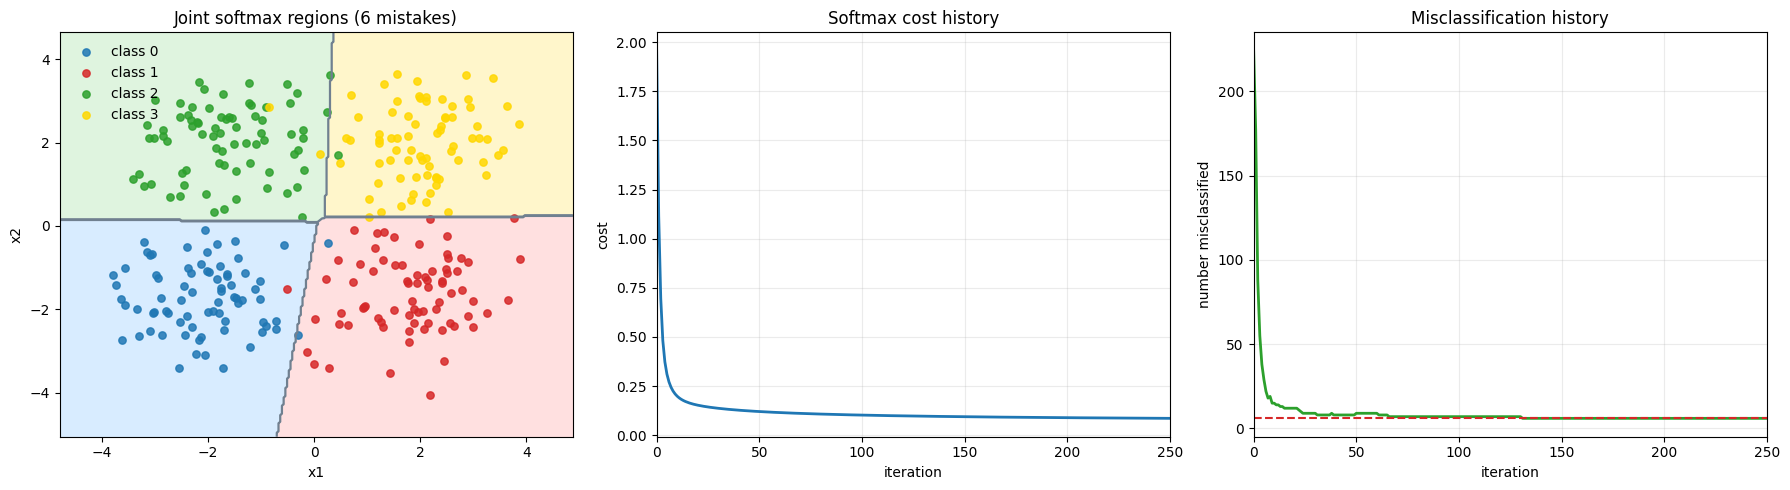

In [4]:
# QUESTION HANDLED: Exercise 7.5 - Multi-class Softmax.
# ---------------------------------------------------------------------
# Repeat the Example 7.4 style experiment using the same 4-class toy dataset
# from Exercise 7.2, but now train one joint multi-class softmax model rather
# than separate OvA models.  The implementation follows the Section 7.3.9
# matrix-based formulation: compute one affine score per class, apply the
# multi-class softmax loss, and optimize all class weights together.
# ---------------------------------------------------------------------

# Train a single joint softmax classifier on the Example 7.4 style dataset.
# Textbook equations used here: the joint multi-class Softmax cost in Equation (7.23)
# together with the matrix implementation pattern from Section 7.3.9.

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS: Chapter 7 classification exercises.
# ---------------------------------------------------------------------
# This cell consolidates the imports, plotting defaults, optimization
# routines, cost functions, prediction helpers, and reusable datasets used
# across the Chapter 7 notebook exercises.  Each exercise cell below repeats these helpers locally so it can run on its own.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Keep all plots on a neutral light background regardless of the notebook's
# previous matplotlib state.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

CLASS_COLORS_4 = ["tab:blue", "tab:red", "tab:green", "gold"]
REGION_CMAP_4 = ListedColormap(["#cfe8ff", "#ffd9d9", "#d8f2d8", "#fff4bf"])
CLASS_COLORS_3 = ["tab:blue", "tab:red", "tab:green"]
REGION_CMAP_3 = ListedColormap(["#d7ebff", "#ffd9d9", "#ddf5dd"])


def linear_model(X, w):
    # Affine score a(x) = w0 + w1 * x1 + ... + wN * xN.
    return w[0] + X @ w[1:]


def sigmoid(z):
    # Logistic sigmoid used in the two-class softmax loss.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))


def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=0.5, max_its=250):
    # Full-batch gradient descent: every update uses the entire training set
    # X, y to compute one exact gradient of the current objective.
    #
    # This is the "normal" gradient descent baseline used in Exercise 7.11.
    # One loop iteration below means:
    # 1. evaluate grad_fn on all training points
    # 2. take one step W <- W - alpha * grad
    # 3. store the updated weights and the full-data cost
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def mini_batch_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, epochs=10, batch_size=200, seed=0):
    # Mini-batch gradient descent: each epoch first shuffles the training set,
    # then breaks it into chunks of size batch_size, and takes one parameter
    # update per chunk.
    #
    # Compared with full-batch gradient descent above, this produces many more
    # cheaper updates per epoch.  The direction of each update is noisier,
    # because it is computed from only part of the data, but in practice this
    # often drives the objective down faster.
    #
    # The full training cost is still recorded only once per epoch so that the
    # resulting history can be compared fairly against full-batch GD.
    rng = np.random.RandomState(seed)
    w = w0.astype(float).copy()
    num_points = X.shape[0]
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(epochs):
        # Randomize the order each epoch so batches do not present the same
        # local view of the data on every pass.
        order = rng.permutation(num_points)
        for start in range(0, num_points, batch_size):
            batch_inds = order[start:start + batch_size]
            # This is the key difference from full-batch GD: the gradient is
            # computed on the current batch only, not on all num_points.
            w = w - alpha * grad_fn(w, X[batch_inds], y[batch_inds])
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def multiclass_scores(X, W):
    # Compute one affine score per class.
    #
    # W has shape (number_of_classes, number_of_features + 1).  The first
    # column stores the class bias terms, and the remaining columns store the
    # feature weights.  For each point x_p this returns the class-score vector
    # [w_0^T xbar_p, ..., w_{C-1}^T xbar_p].
    return W[:, 0][None, :] + X @ W[:, 1:].T


def multiclass_predict(X, W):
    # Predict the class whose score is largest.
    return np.argmax(multiclass_scores(X, W), axis=1)


def misclassifications_multiclass(preds, y):
    return int(np.sum(preds != y))


def misclass_history(X, y, weight_history, predict_fn=multiclass_predict):
    # Count mistakes after each saved iterate.
    return np.array([
        misclassifications_multiclass(predict_fn(X, weights), y)
        for weights in weight_history
    ])


def one_vs_all_labels(y, target_class):
    # Temporary labels for one-versus-all training: +1 for class c, -1 otherwise.
    return np.where(y == target_class, 1.0, -1.0)


def signed_distance_scores(X, w, eps=1e-12):
    # Normalize by the feature-weight norm so OvA scores are comparable.
    norm_omega = max(np.linalg.norm(w[1:]), eps)
    return linear_model(X, w) / norm_omega


def ova_predict(X, classifiers):
    # Evaluate all one-versus-all classifiers and choose the largest normalized
    # signed distance.
    fusion_scores = np.column_stack([signed_distance_scores(X, w) for w in classifiers])
    return np.argmax(fusion_scores, axis=1)


def softmax_cost_signed(w, X, y):
    # Two-class softmax loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))


def grad_softmax_signed(w, X, y):
    # Gradient of the signed softmax loss.
    margins = y * linear_model(X, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X.T @ coeff) / X.shape[0]
    return np.concatenate([[grad_w0], grad_rest])


def multiclass_perceptron_cost(W, X, y):
    # Compare the true-class score against the strongest competing class score.
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(X.shape[0]), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(X.shape[0]), y] = -np.inf
    worst_margin = np.max(margins, axis=1)
    return np.mean(np.maximum(0.0, worst_margin))


def multiclass_perceptron_gradient(W, X, y):
    # Subgradient of the multiclass perceptron cost.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(num_points), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(num_points), y] = -np.inf
    worst_classes = np.argmax(margins, axis=1)
    worst_margins = margins[np.arange(num_points), worst_classes]

    gradient = np.zeros_like(W)
    active = np.where(worst_margins > 0)[0]
    if active.size == 0:
        return gradient

    X_aug = np.column_stack([np.ones(num_points), X]) / num_points
    np.add.at(gradient, worst_classes[active], X_aug[active])
    np.add.at(gradient, y[active], -X_aug[active])
    return gradient


def multiclass_softmax_cost(W, X, y, lam=1e-4):
    # Stable multiclass softmax cost with a small L2 penalty on feature weights.
    #
    # For each point p with true class y_p, the data-fitting term is
    #
    #   log(sum_j exp(score_{p,j})) - score_{p, y_p}
    #
    # which penalizes the model unless the true-class score is large relative
    # to the scores of all competing classes.
    #
    # We subtract the largest score in each row before exponentiating.  This
    # leaves the softmax value unchanged but prevents numerical overflow.
    scores = multiclass_scores(X, W)
    row_max = np.max(scores, axis=1, keepdims=True)
    stabilized_scores = scores - row_max
    log_partition = np.log(np.sum(np.exp(stabilized_scores), axis=1)) + row_max.ravel()
    data_cost = np.mean(log_partition - scores[np.arange(X.shape[0]), y])
    # Regularize only the feature weights, not the bias column.
    regularizer = 0.5 * lam * np.sum(W[:, 1:] ** 2)
    return data_cost + regularizer


def multiclass_softmax_gradient(W, X, y, lam=1e-4):
    # Gradient of the multiclass softmax cost.
    #
    # After converting scores into softmax probabilities p_{p,j}, the gradient
    # is driven by the difference between those probabilities and a one-hot
    # encoding of the true label.  In symbols, the score-level residual is
    #
    #   p_{p,j} - 1(j = y_p)
    #
    # The matrix multiply against X_aug then turns those residuals into one
    # gradient row per class.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    stabilized_scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(stabilized_scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # targets[p, j] equals 1 exactly when class j is the true class for point p.
    targets = np.zeros_like(probabilities)
    targets[np.arange(num_points), y] = 1.0

    # Augment each input with a leading 1 so the bias gradient and feature
    # gradients can be computed in one matrix multiply.
    X_aug = np.column_stack([np.ones(num_points), X])
    gradient = ((probabilities - targets).T @ X_aug) / num_points
    # Again, regularize only the feature weights.
    gradient[:, 1:] += lam * W[:, 1:]
    return gradient


def make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75):
    # Synthetic four-class dataset used for Exercises 7.2 and 7.5.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.0, -1.6],
        [-1.7,  2.1],
        [ 2.0,  2.0],
    ])
    cov = np.array([[std, 0.12], [0.12, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_perceptron_toy_dataset(seed=4, n_per_class=60, std=0.30):
    # Synthetic three-class dataset used for Exercise 7.3.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.2, -1.6],
        [ 0.1,  2.4],
    ])
    cov = np.array([[std, 0.05], [0.05, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_decision_grid(X, pad=1.0, num=300):
    # Build a dense 2D grid for region and contour plots.
    x1_vals = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, num)
    x2_vals = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, num)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])
    return x1_vals, x2_vals, X1, X2, X_grid


def plot_class_scatter(ax, X, y, class_colors, size=28, alpha=0.85, add_labels=False):
    # Scatter plot of a 2D labeled dataset.
    for c, color in enumerate(class_colors):
        kwargs = {"label": f"class {c}"} if add_labels else {}
        ax.scatter(X[y == c, 0], X[y == c, 1], s=size, color=color, alpha=alpha, **kwargs)


def load_local_digits_data(test_size=0.25, random_state=7):
    # Local handwritten-digit dataset used as a self-contained fallback for the
    # chapter's digit-recognition experiment.
    X_digits, y_digits = load_digits(return_X_y=True)
    X_digits = X_digits.astype(float) / 16.0
    return train_test_split(
        X_digits,
        y_digits,
        test_size=test_size,
        random_state=random_state,
        stratify=y_digits,
    )

X_sm, y_sm = make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75)
num_classes_sm = len(np.unique(y_sm))
W_init_sm = np.random.RandomState(0).randn(num_classes_sm, X_sm.shape[1] + 1)
softmax_lam = 1e-4

W_history_sm, cost_history_sm = gradient_descent(
    lambda W, X, y: multiclass_softmax_cost(W, X, y, lam=softmax_lam),
    lambda W, X, y: multiclass_softmax_gradient(W, X, y, lam=softmax_lam),
    W_init_sm,
    X_sm,
    y_sm,
    alpha=0.5,
    max_its=250,
)

misclass_history_sm = misclass_history(X_sm, y_sm, W_history_sm)
best_step_sm = int(np.argmin(misclass_history_sm))
W_best_sm = W_history_sm[best_step_sm]
best_misclassifications_sm = int(misclass_history_sm[best_step_sm])
final_misclassifications_sm = int(misclass_history_sm[-1])

print('Final misclassifications:', final_misclassifications_sm)
print('Minimum misclassifications during optimization:', best_misclassifications_sm)
print('Best iterate index:', best_step_sm)
print('Target: small number of misclassifications (10 or fewer is a good match to the text)')

# Visualize the fused softmax regions together with the optimization traces.
class_colors_sm = CLASS_COLORS_4
region_cmap_sm = REGION_CMAP_4
x1_vals_sm, x2_vals_sm, X1_sm, X2_sm, X_grid_sm = make_decision_grid(X_sm, pad=1.0, num=300)
grid_predictions_sm = multiclass_predict(X_grid_sm, W_best_sm).reshape(X1_sm.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].contourf(
    X1_sm,
    X2_sm,
    grid_predictions_sm,
    levels=np.arange(num_classes_sm + 1) - 0.5,
    cmap=region_cmap_sm,
    alpha=0.80,
)
axes[0].contour(
    X1_sm,
    X2_sm,
    grid_predictions_sm,
    levels=np.arange(num_classes_sm - 1) + 0.5,
    colors=['slategray'],
    linewidths=1.6,
)
plot_class_scatter(axes[0], X_sm, y_sm, class_colors_sm, size=28, alpha=0.85, add_labels=True)
axes[0].set_title(f'Joint softmax regions ({best_misclassifications_sm} mistakes)')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].legend(frameon=False, loc='upper left')
axes[0].set_xlim(x1_vals_sm.min(), x1_vals_sm.max())
axes[0].set_ylim(x2_vals_sm.min(), x2_vals_sm.max())

axes[1].plot(cost_history_sm, color='tab:blue', linewidth=2)
axes[1].set_title('Softmax cost history')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('cost')
axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, len(cost_history_sm) - 1)

axes[2].plot(misclass_history_sm, color='tab:green', linewidth=2)
axes[2].axhline(best_misclassifications_sm, color='tab:red', linestyle='--', linewidth=1.5)
axes[2].set_title('Misclassification history')
axes[2].set_xlabel('iteration')
axes[2].set_ylabel('number misclassified')
axes[2].grid(alpha=0.25)
axes[2].set_xlim(0, len(misclass_history_sm) - 1)

plt.tight_layout()
plt.show()


Dataset used: scikit-learn digits (8x8 handwritten images)
Training samples: 1347 | Test samples: 450
Full-batch final train/test misclassifications: 133 46
Mini-batch final train/test misclassifications: 69 27


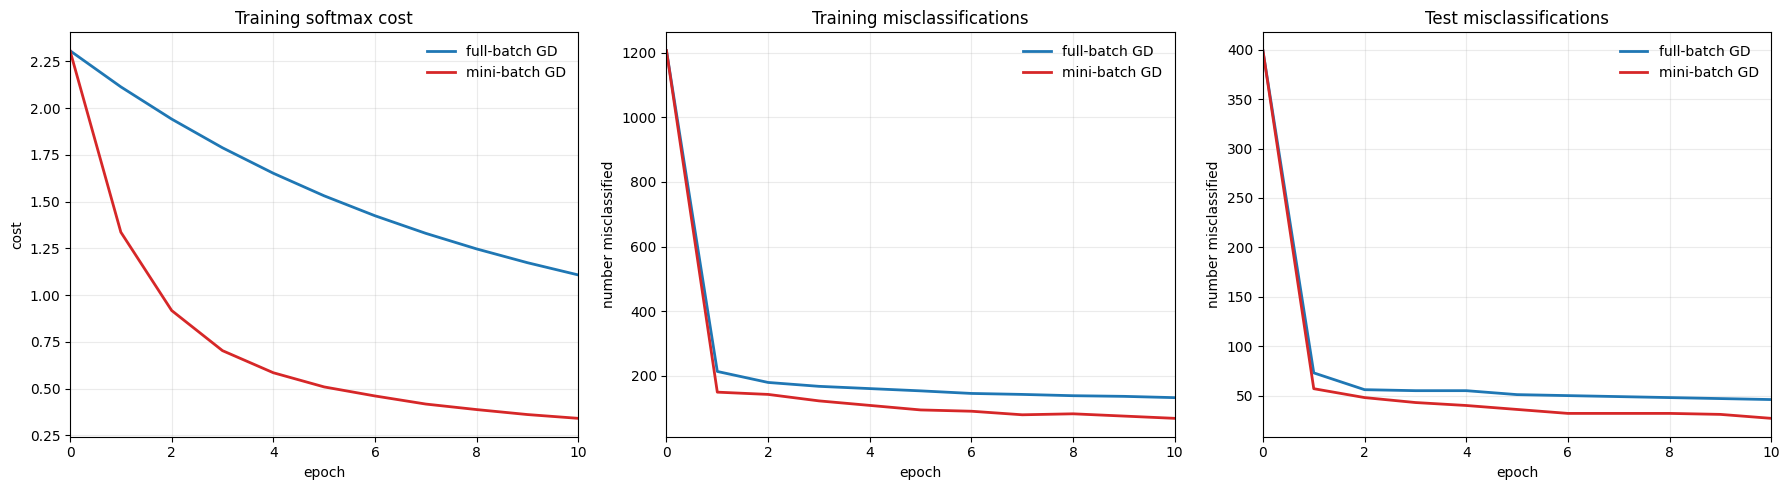

In [5]:
# QUESTION HANDLED: Exercise 7.11 - Recognizing handwritten digits.
# ---------------------------------------------------------------------
# Recreate the general Example 7.10 result by training a multi-class softmax
# classifier on a handwritten-digit dataset using mini-batch gradient descent.
# The book uses a larger handwritten-digit collection; here we use scikit-
# learn's built-in local digits dataset so the notebook remains self-contained.
# We compare standard full-batch gradient descent against mini-batch gradient
# descent and verify that mini-batching reaches lower error more quickly.
# ---------------------------------------------------------------------

# Load a local handwritten-digit dataset, scale the pixel values into [0, 1],
# and create a stratified train/test split.
# Textbook equations used here: the multi-class Softmax cost in Equation (7.23)
# and the mini-batch optimization discussion in Section 7.8 / Appendix A.5.

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS: Chapter 7 classification exercises.
# ---------------------------------------------------------------------
# This cell consolidates the imports, plotting defaults, optimization
# routines, cost functions, prediction helpers, and reusable datasets used
# across the Chapter 7 notebook exercises.  Each exercise cell below repeats these helpers locally so it can run on its own.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Keep all plots on a neutral light background regardless of the notebook's
# previous matplotlib state.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

CLASS_COLORS_4 = ["tab:blue", "tab:red", "tab:green", "gold"]
REGION_CMAP_4 = ListedColormap(["#cfe8ff", "#ffd9d9", "#d8f2d8", "#fff4bf"])
CLASS_COLORS_3 = ["tab:blue", "tab:red", "tab:green"]
REGION_CMAP_3 = ListedColormap(["#d7ebff", "#ffd9d9", "#ddf5dd"])


def linear_model(X, w):
    # Affine score a(x) = w0 + w1 * x1 + ... + wN * xN.
    return w[0] + X @ w[1:]


def sigmoid(z):
    # Logistic sigmoid used in the two-class softmax loss.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))


def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=0.5, max_its=250):
    # Full-batch gradient descent: every update uses the entire training set
    # X, y to compute one exact gradient of the current objective.
    #
    # This is the "normal" gradient descent baseline used in Exercise 7.11.
    # One loop iteration below means:
    # 1. evaluate grad_fn on all training points
    # 2. take one step W <- W - alpha * grad
    # 3. store the updated weights and the full-data cost
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def mini_batch_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, epochs=10, batch_size=200, seed=0):
    # Mini-batch gradient descent: each epoch first shuffles the training set,
    # then breaks it into chunks of size batch_size, and takes one parameter
    # update per chunk.
    #
    # Compared with full-batch gradient descent above, this produces many more
    # cheaper updates per epoch.  The direction of each update is noisier,
    # because it is computed from only part of the data, but in practice this
    # often drives the objective down faster.
    #
    # The full training cost is still recorded only once per epoch so that the
    # resulting history can be compared fairly against full-batch GD.
    rng = np.random.RandomState(seed)
    w = w0.astype(float).copy()
    num_points = X.shape[0]
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(epochs):
        # Randomize the order each epoch so batches do not present the same
        # local view of the data on every pass.
        order = rng.permutation(num_points)
        for start in range(0, num_points, batch_size):
            batch_inds = order[start:start + batch_size]
            # This is the key difference from full-batch GD: the gradient is
            # computed on the current batch only, not on all num_points.
            w = w - alpha * grad_fn(w, X[batch_inds], y[batch_inds])
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)


def multiclass_scores(X, W):
    # Compute one affine score per class.
    #
    # W has shape (number_of_classes, number_of_features + 1).  The first
    # column stores the class bias terms, and the remaining columns store the
    # feature weights.  For each point x_p this returns the class-score vector
    # [w_0^T xbar_p, ..., w_{C-1}^T xbar_p].
    return W[:, 0][None, :] + X @ W[:, 1:].T


def multiclass_predict(X, W):
    # Predict the class whose score is largest.
    return np.argmax(multiclass_scores(X, W), axis=1)


def misclassifications_multiclass(preds, y):
    return int(np.sum(preds != y))


def misclass_history(X, y, weight_history, predict_fn=multiclass_predict):
    # Count mistakes after each saved iterate.
    return np.array([
        misclassifications_multiclass(predict_fn(X, weights), y)
        for weights in weight_history
    ])


def one_vs_all_labels(y, target_class):
    # Temporary labels for one-versus-all training: +1 for class c, -1 otherwise.
    return np.where(y == target_class, 1.0, -1.0)


def signed_distance_scores(X, w, eps=1e-12):
    # Normalize by the feature-weight norm so OvA scores are comparable.
    norm_omega = max(np.linalg.norm(w[1:]), eps)
    return linear_model(X, w) / norm_omega


def ova_predict(X, classifiers):
    # Evaluate all one-versus-all classifiers and choose the largest normalized
    # signed distance.
    fusion_scores = np.column_stack([signed_distance_scores(X, w) for w in classifiers])
    return np.argmax(fusion_scores, axis=1)


def softmax_cost_signed(w, X, y):
    # Two-class softmax loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))


def grad_softmax_signed(w, X, y):
    # Gradient of the signed softmax loss.
    margins = y * linear_model(X, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X.T @ coeff) / X.shape[0]
    return np.concatenate([[grad_w0], grad_rest])


def multiclass_perceptron_cost(W, X, y):
    # Compare the true-class score against the strongest competing class score.
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(X.shape[0]), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(X.shape[0]), y] = -np.inf
    worst_margin = np.max(margins, axis=1)
    return np.mean(np.maximum(0.0, worst_margin))


def multiclass_perceptron_gradient(W, X, y):
    # Subgradient of the multiclass perceptron cost.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    correct_scores = scores[np.arange(num_points), y]
    margins = scores - correct_scores[:, None]
    margins[np.arange(num_points), y] = -np.inf
    worst_classes = np.argmax(margins, axis=1)
    worst_margins = margins[np.arange(num_points), worst_classes]

    gradient = np.zeros_like(W)
    active = np.where(worst_margins > 0)[0]
    if active.size == 0:
        return gradient

    X_aug = np.column_stack([np.ones(num_points), X]) / num_points
    np.add.at(gradient, worst_classes[active], X_aug[active])
    np.add.at(gradient, y[active], -X_aug[active])
    return gradient


def multiclass_softmax_cost(W, X, y, lam=1e-4):
    # Stable multiclass softmax cost with a small L2 penalty on feature weights.
    #
    # For each point p with true class y_p, the data-fitting term is
    #
    #   log(sum_j exp(score_{p,j})) - score_{p, y_p}
    #
    # which penalizes the model unless the true-class score is large relative
    # to the scores of all competing classes.
    #
    # We subtract the largest score in each row before exponentiating.  This
    # leaves the softmax value unchanged but prevents numerical overflow.
    scores = multiclass_scores(X, W)
    row_max = np.max(scores, axis=1, keepdims=True)
    stabilized_scores = scores - row_max
    log_partition = np.log(np.sum(np.exp(stabilized_scores), axis=1)) + row_max.ravel()
    data_cost = np.mean(log_partition - scores[np.arange(X.shape[0]), y])
    # Regularize only the feature weights, not the bias column.
    regularizer = 0.5 * lam * np.sum(W[:, 1:] ** 2)
    return data_cost + regularizer


def multiclass_softmax_gradient(W, X, y, lam=1e-4):
    # Gradient of the multiclass softmax cost.
    #
    # After converting scores into softmax probabilities p_{p,j}, the gradient
    # is driven by the difference between those probabilities and a one-hot
    # encoding of the true label.  In symbols, the score-level residual is
    #
    #   p_{p,j} - 1(j = y_p)
    #
    # The matrix multiply against X_aug then turns those residuals into one
    # gradient row per class.
    num_points = X.shape[0]
    scores = multiclass_scores(X, W)
    stabilized_scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(stabilized_scores)
    probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # targets[p, j] equals 1 exactly when class j is the true class for point p.
    targets = np.zeros_like(probabilities)
    targets[np.arange(num_points), y] = 1.0

    # Augment each input with a leading 1 so the bias gradient and feature
    # gradients can be computed in one matrix multiply.
    X_aug = np.column_stack([np.ones(num_points), X])
    gradient = ((probabilities - targets).T @ X_aug) / num_points
    # Again, regularize only the feature weights.
    gradient[:, 1:] += lam * W[:, 1:]
    return gradient


def make_ova_toy_dataset(seed=3, n_per_class=75, std=0.75):
    # Synthetic four-class dataset used for Exercises 7.2 and 7.5.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.0, -1.6],
        [-1.7,  2.1],
        [ 2.0,  2.0],
    ])
    cov = np.array([[std, 0.12], [0.12, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_perceptron_toy_dataset(seed=4, n_per_class=60, std=0.30):
    # Synthetic three-class dataset used for Exercise 7.3.
    rng = np.random.RandomState(seed)
    means = np.array([
        [-2.2, -1.8],
        [ 2.2, -1.6],
        [ 0.1,  2.4],
    ])
    cov = np.array([[std, 0.05], [0.05, std]])

    X_blocks = []
    y_blocks = []
    for c, mean in enumerate(means):
        X_c = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_c = np.full(n_per_class, c)
        X_blocks.append(X_c)
        y_blocks.append(y_c)

    return np.vstack(X_blocks), np.concatenate(y_blocks)


def make_decision_grid(X, pad=1.0, num=300):
    # Build a dense 2D grid for region and contour plots.
    x1_vals = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, num)
    x2_vals = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, num)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])
    return x1_vals, x2_vals, X1, X2, X_grid


def plot_class_scatter(ax, X, y, class_colors, size=28, alpha=0.85, add_labels=False):
    # Scatter plot of a 2D labeled dataset.
    for c, color in enumerate(class_colors):
        kwargs = {"label": f"class {c}"} if add_labels else {}
        ax.scatter(X[y == c, 0], X[y == c, 1], s=size, color=color, alpha=alpha, **kwargs)


def load_local_digits_data(test_size=0.25, random_state=7):
    # Local handwritten-digit dataset used as a self-contained fallback for the
    # chapter's digit-recognition experiment.
    X_digits, y_digits = load_digits(return_X_y=True)
    X_digits = X_digits.astype(float) / 16.0
    return train_test_split(
        X_digits,
        y_digits,
        test_size=test_size,
        random_state=random_state,
        stratify=y_digits,
    )

X_train_digits, X_test_digits, y_train_digits, y_test_digits = load_local_digits_data(test_size=0.25, random_state=7)
num_classes_digits = len(np.unique(y_train_digits))
# The weight matrix has one row per digit class.  The extra +1 column is for
# the bias term, so with 64 input features we learn a 10 x 65 parameter matrix.
# The small random scale keeps the initial class scores near zero.
W_init_digits = 0.01 * np.random.RandomState(0).randn(num_classes_digits, X_train_digits.shape[1] + 1)

# Hyperparameters shared by both optimizers so the comparison is apples-to-apples.
alpha_digits = 1.0
epochs_digits = 10
batch_size_digits = 200
lam_digits = 1e-4

# Run both optimizers from the same initialization so the comparison is fair.
# Full-batch GD takes one update per epoch using all 1347 training examples.
full_weight_history_digits, full_cost_history_digits = gradient_descent(
    lambda W, X, y: multiclass_softmax_cost(W, X, y, lam=lam_digits),
    lambda W, X, y: multiclass_softmax_gradient(W, X, y, lam=lam_digits),
    W_init_digits,
    X_train_digits,
    y_train_digits,
    alpha=alpha_digits,
    max_its=epochs_digits,
)

# Mini-batch GD sees the same data each epoch, but after shuffling it performs
# several cheaper updates, one for each chunk of 200 points.  Since 1347 / 200
# is about 6.7, this gives roughly 7 updates per epoch instead of 1.
mini_weight_history_digits, mini_cost_history_digits = mini_batch_gradient_descent(
    lambda W, X, y: multiclass_softmax_cost(W, X, y, lam=lam_digits),
    lambda W, X, y: multiclass_softmax_gradient(W, X, y, lam=lam_digits),
    W_init_digits,
    X_train_digits,
    y_train_digits,
    alpha=alpha_digits,
    epochs=epochs_digits,
    batch_size=batch_size_digits,
    seed=0,
)

# Evaluate every saved iterate on the full training and test sets so the plots
# show how the two optimization schemes compare over the same epoch timeline.
full_train_misclass_digits = misclass_history(X_train_digits, y_train_digits, full_weight_history_digits)
mini_train_misclass_digits = misclass_history(X_train_digits, y_train_digits, mini_weight_history_digits)
full_test_misclass_digits = misclass_history(X_test_digits, y_test_digits, full_weight_history_digits)
mini_test_misclass_digits = misclass_history(X_test_digits, y_test_digits, mini_weight_history_digits)

# Both histories contain the initial untrained model plus one entry per epoch,
# so the x-axis runs from 0 through epochs_digits.
epoch_axis_digits = np.arange(epochs_digits + 1)

print('Dataset used: scikit-learn digits (8x8 handwritten images)')
print('Training samples:', X_train_digits.shape[0], '| Test samples:', X_test_digits.shape[0])
print('Full-batch final train/test misclassifications:', int(full_train_misclass_digits[-1]), int(full_test_misclass_digits[-1]))
print('Mini-batch final train/test misclassifications:', int(mini_train_misclass_digits[-1]), int(mini_test_misclass_digits[-1]))

# Plot the optimization comparison.  The general Example 7.10 behavior should
# appear here: mini-batching drives the cost and mistake counts down faster.
# The left panel is optimization objective, the middle panel is training error,
# and the right panel is held-out test error.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epoch_axis_digits, full_cost_history_digits, color='tab:blue', linewidth=2, label='full-batch GD')
axes[0].plot(epoch_axis_digits, mini_cost_history_digits, color='tab:red', linewidth=2, label='mini-batch GD')
axes[0].set_title('Training softmax cost')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('cost')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(epoch_axis_digits, full_train_misclass_digits, color='tab:blue', linewidth=2, label='full-batch GD')
axes[1].plot(epoch_axis_digits, mini_train_misclass_digits, color='tab:red', linewidth=2, label='mini-batch GD')
axes[1].set_title('Training misclassifications')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('number misclassified')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

axes[2].plot(epoch_axis_digits, full_test_misclass_digits, color='tab:blue', linewidth=2, label='full-batch GD')
axes[2].plot(epoch_axis_digits, mini_test_misclass_digits, color='tab:red', linewidth=2, label='mini-batch GD')
axes[2].set_title('Test misclassifications')
axes[2].set_xlabel('epoch')
axes[2].set_ylabel('number misclassified')
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False)

for ax in axes:
    ax.set_xlim(0, epochs_digits)

plt.tight_layout()
plt.show()
